# Naive Bayes Reseñas Playstore

### Carga de datos

In [26]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier

import pickle

In [17]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/playstore_reviews.csv')
df

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0
...,...,...,...
886,com.rovio.angrybirds,loved it i loooooooooooooovvved it because it...,1
887,com.rovio.angrybirds,all time legendary game the birthday party le...,1
888,com.rovio.angrybirds,ads are way to heavy listen to the bad review...,0
889,com.rovio.angrybirds,fun works perfectly well. ads aren't as annoy...,1


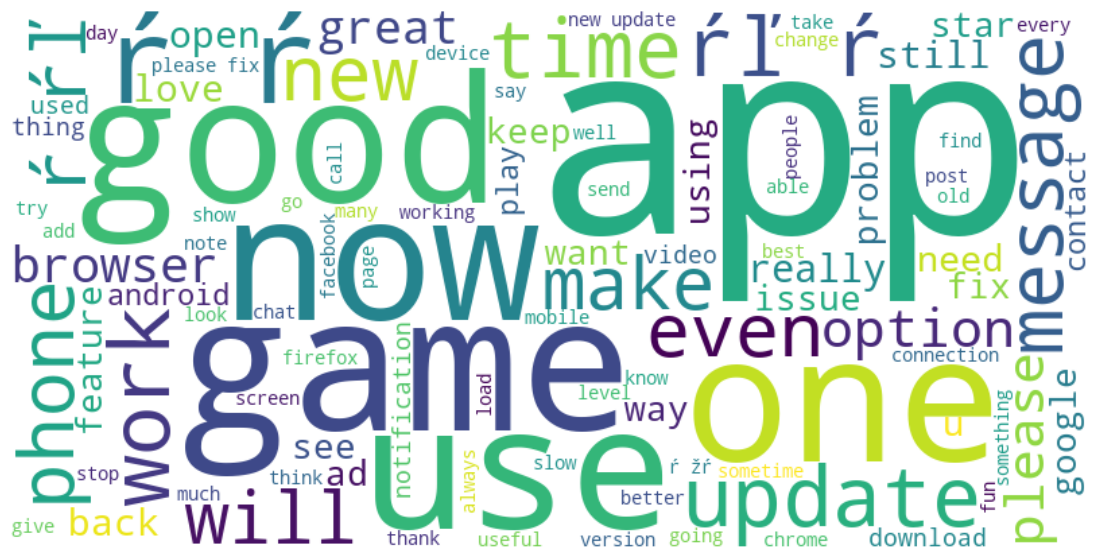

In [30]:
# Si no la tienes instalada: !pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Unir todas las reseñas en un solo texto largo
texto_completo = " ".join(review for review in df.review.astype(str))

# 2. Configurar la nube de palabras
# Añadimos stopwords para evitar palabras como "the", "a", "is" que no aportan valor
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis',
    max_words=100,
    stopwords=None # WordCloud ya trae una lista por defecto, pero puedes pasarle una personalizada
).generate(texto_completo)

# 3. Mostrar el gráfico
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Ocultamos los ejes
plt.show()

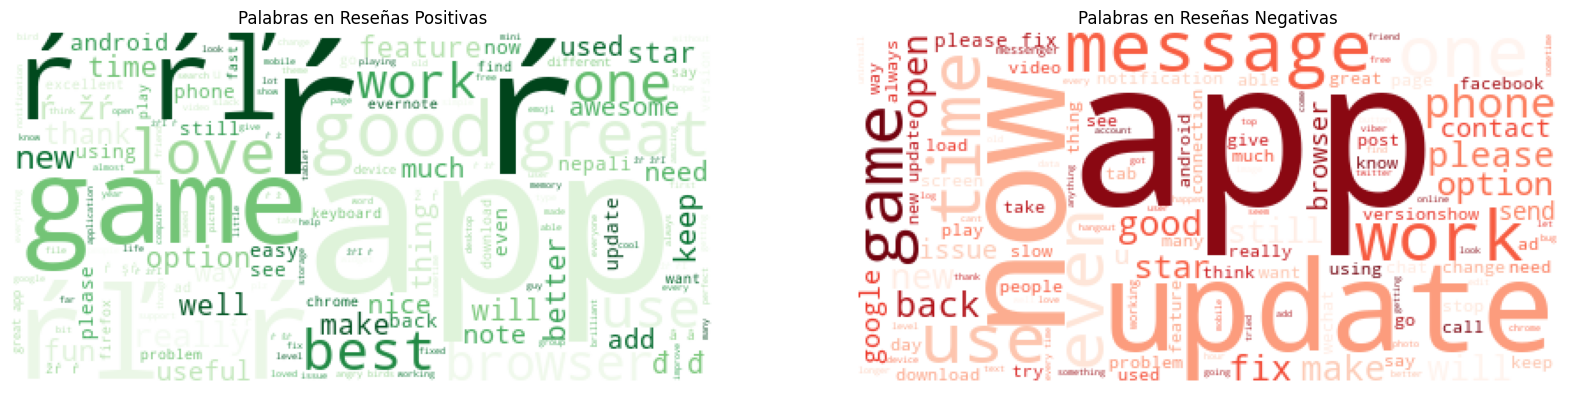

In [31]:
# Palabras en reseñas positivas (polarity == 1)
texto_pos = " ".join(df[df['polarity'] == 1].review.astype(str))
wc_pos = WordCloud(background_color="white", colormap="Greens").generate(texto_pos)

# Palabras en reseñas negativas (polarity == 0)
texto_neg = " ".join(df[df['polarity'] == 0].review.astype(str))
wc_neg = WordCloud(background_color="white", colormap="Reds").generate(texto_neg)

# Dibujar ambas
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(wc_pos)
ax[0].set_title('Palabras en Reseñas Positivas')
ax[0].axis('off')
ax[1].imshow(wc_neg)
ax[1].set_title('Palabras en Reseñas Negativas')
ax[1].axis('off')
plt.show()

### Limpieza y Selección de variables

In [18]:
df['review'] = df['review'].str.strip().str.lower()

# Solo nos interesa la reseña como predictora
X = df['review'] 
y = df['polarity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Vectorización (Convertir texto a números)

In [21]:
vec_model = CountVectorizer(stop_words="english")
X_train_vec = vec_model.fit_transform(X_train).toarray()
X_test_vec = vec_model.transform(X_test).toarray()

### Entrenamiento

Opciones de Naive Bayes a elegir:

MultinomialNB: El ideal para conteo de palabras (frecuencias). La mejor opción aquí.

BernoulliNB: Útil si solo importa si una palabra aparece o no (presencia/ausencia), no cuántas veces.

GaussianNB: Se usa para datos que siguen una distribución normal (continuos), no es eficiente para matrices dispersas de texto.

In [23]:
# Prueba con Multinomial (recomendado)
nb_multinomial = MultinomialNB()
nb_multinomial.fit(X_train_vec, y_train)

y_pred = nb_multinomial.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       126
           1       0.73      0.60      0.66        53

    accuracy                           0.82       179
   macro avg       0.79      0.75      0.77       179
weighted avg       0.81      0.82      0.81       179



Da muy bien

## Prueba con Ramdon Forest

In [25]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_vec, y_train)

print(f"RF Accuracy: {rf_model.score(X_test_vec, y_test)}")

RF Accuracy: 0.7988826815642458


In [28]:
y_pred_rf = rf_model.predict(X_test_vec)

# 2. Imprimimos el reporte comparando con los datos reales
print("--- Reporte Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Reporte Random Forest ---
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       126
           1       0.64      0.74      0.68        53

    accuracy                           0.80       179
   macro avg       0.76      0.78      0.77       179
weighted avg       0.81      0.80      0.80       179



### El modelo Naive Bayes (Multinomial) es superior al Random Forest para este problema específico

Naive Bayes gana en Rendimiento General:

Accuracy (Exactitud): Naive Bayes alcanza un 82%, mientras que Random Forest se queda en un 80%.

F1-Score (Equilibrio): El F1-score de Naive Bayes para la clase 0 (negativos) es muy alto (0.87), lo que indica que es excelente detectando críticas negativas.

Desbalanceo (Clase 1): En el support se observan 126 ejemplos de clase 0 y solo 53 de clase 1. Esto hace que a ambos modelos les cueste más predecir los comentarios positivos (clase 1).

En Naive Bayes, el Recall de la clase 1 es 0.60. Esto significa que el modelo solo identifica correctamente el 60% de los comentarios positivos reales; el otro 40% los confunde con negativos.

## Guardado del proyecto

In [27]:
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_multinomial, f)